# Evaluating the Equity of Urban Heat Mitigation in Transit-Oriented Development Districts in Maryland
### An assessment of tree canopy, land surface temperature, and environmental justice
**Author:** Siddhi Pawar <br>
**Course:** URSP688Y: Urban Data Science & Smart Cities <br>
**Professor:** Dr. Chester Harvery <br>
**Date:** May 13, 2026 <br>

---  

## Research Question <br>
How are environmental conditions, including land surface temperature (LST) and tree canopy coverage, associated with the level of transit-oriented development (TOD) exposure within census tracts across Maryland, and how do these patterns differ across socioeconomic characteristics? <br>

TOD exposure is measured as the proportion of each census tract's area that overlaps with Maryland's state-defined TOD boundaries. Proportions will be classified as tracts with no TOD exposure (area % = 0), either within a one-mile buffer or outside of it, tracts with low exposure (0 < area % < 50), and tracts with high exposure (area % >= 50). <br>

 --- 

## Approach <br>
### ArcGIS Pro Analysis: <br>
**PHASE 1 - ArcGIS Spatial Data Setup** <br>
**1a.** Add Maryland state boundary, Maryland designated TOD, and Census tract (ACS 2024) shapefiles <br>
**1b.** Add LST Landsat 8/9 scene, NLCD CONUS tree canopy coverage, and NLCD fractional impervious surface rasters <br>
**1c.** Project everything to NAD 1983 StatePlan Maryland FIPS 1900 (US Feet) <br>
**1d.** Extract the tree canopy and impervious surface raster to the mask extent of the Maryland boundary (to concentrate the analysis scale to the state) <br>
**1e.** Use the Zonal Statistics tool to gather LST, tree canopy, and impervious surface data for the Census tracts <br>
**1f.** Export CSVs and shapefiles <br>

### Python Analysis: <br>
**PHASE 2 - Python Spatial Data Setup <br>**
**2a.** Load Maryland TOD boundaries and Census tracts <br>
**2b.** Confirm projections and project again if necessary <br>
**2c.** Create the TOD exposure distinctions/classifications --> <br>
        - Intersect the Census tracts with the TOD polygons <br>
        - Divide the area of the intersection with the total area of the Census tract <br>
        - Assign a value of 0 to tracts with no overlap <br>
**2d.** Classify the tracts for mapping and summary purposes <br>
        - No TOD: 0% exposure or overlap of tract <br>
        - Low TOD: 0% < exposure or overlap of tract <= 50% <br>
        - High TOD: exposure or overlap of tract > 50% <br>

**PHASE 3 - Demographic Data <br>**
**3a.** Pull 2024 5-year estimates ACS data through a Census API <br>
        - Median household income <br>
        - Total population <br>
        - Race and ethnicity <br>

**PHASE 4 - Environmental Data Integration <br>**
**4a.** Load the zonal statistics CSVs from ArcGIS Pro to this notebook <br>
        - LST CSV = mean LST (in fahrenheit) for each Census tract <br>
        - Tree canopy CSV = mean tree canopy (%) for each Census tract <br>
        - Impervious surface CSV = mean impervious surface (%) for each Census tract <br>
**4b.** Align GEOIDs from the CSVs and Census tracts. Then merge all CSVs to Census tract dataframe <br>
**4c.** Merge ACS data to the tract GEOID <br>
**4d.** Calculate population density and display the final dataframe <br>

**PHASE 5 - Analysis and Visualization <br>**
**5a.** Create a summary statistics table for the final dataframe <br>
**5b.** Create bar charts for TOD exposure/category comparison <br>
**5c.** Create scatterplots for... <br>
        - Tree canopy vs LST <br>
        - Income vs Tree canopy <br>
        - Income vs LST <br>
        - Race vs Tree canopy <br>
        - Race vs LST <br>
**5d** Run an Ordinary Least Squares (OLS) regression to isolate the variable for LST


In [78]:
#Import the necessary packages
import pandas as pd
import geopandas as gpd
import requests
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

## PHASE 1 - ARCGIS PRO SPATIAL SETUP

### 1a. Import state boundaries, 2024 Census tract boundaries, and Maryland designated TOD shapefiles into a new ArcGIS Pro project

In [79]:
# The state boundaries shapefile contained all of the states in the US, so Maryland was selected and created into an individual feature layer while the remainder the 
# layer was turned off.

### 1b. Import LST Landsat 8/9 scene, NLCD CONUS tree canopy coverage, and NLCD fractional impervious surface rasters into the ArcGIS Pro project

In [80]:
# The downloaded satellite scene was of Path 15, Row 33 from August 24, 2024 which contained less than 10% cloud coverage. While this scene does not cover all of Maryland,
# it covers all of the TOD areas.
# Of this, the extracted TIF file came from the Surface Temperature band (ST_B10.TIF) which has the land surface temperatures.
# Values from this band were converted from Kelvin to Fahrenheit using the "Calculate Raster" tool in ArcGIS.

### 1c. Project everything to NAD 1983 Stateplan Maryland FIPS 1900 (US Feet)

In [54]:
# A model in "Model Builder" was created to project all of the raster and shapefiles. This helped keep everything organized. 
# The "Project" tool was used for the Maryland boundary, TOD, and Census tracts shapefiles. 
# The "Project Raster" tool was used for the LST, tree canopy coverage, and impervious surface rasters. 
# The projected coordinate system was NAD 1983 StatePlan Maryland FIPS 1900 (US Feet).
# Projected versions of each file were then created and outputted from the model. 

### 1d. Clip the tree canopy coverage and impervious surface rasters to the Maryland state boundary

In [55]:
# Because NLCD provides data and rasters at the national level, the downloaded tree canopy coverage and impervious surface data was representative of the state. 
# To limit data processing and overload, the "Extract by Mask" tool was used for both rasters, where the data for both was cliped to the extent of Maryland, provided by the 
# Maryland feature layer.

### 1e. Use the Zonal Statistics tool to attribute the LST, tree canopy coverage, and impervious surface data to each Census tract

In [56]:
# In the "Model Builder", the "Zonal Statistics as a Table" tool was used to capture the mean or average values for LST, tree canopy, and impervious surface for each Census tract.
# The Census tract was used at the feature zone data, given this is the unit of analysis, and the corresponsing rasters were used as the "Input Value Raster". 
# The tract GEOID was used as the unique identifier of each tract, which will come in handy later with ACS data.

### 1f. Export the final tables as CSVs and export the projected shapefiles for Pyton upload

In [81]:
# Finally, after the tool ran, CSVs for the created LST, tree canopy, and impervious surface datasets were exported using the "Export Table" tool.
# The projected shapefiles for the Maryland TOD boundaries and Census tracts were also exported
# Together, the two shapefiles and three CSVs must be exported for the second phase of this project, which is featured below. 

## PHASE 2 - PYTHON SPATIAL SETUP

### 2a. Load Maryland Boundaries and Census tracts (available in Shared Drive)

In [82]:
#Start spatial setup of the Census tracts and TOD files

#Load Maryland Census tracts (ACS 2024)
census_tracts = gpd.read_file("2024_Census_Tracts/2024_Census_Tracts.shp")

#Load Maryland TOD boundaries
TOD = gpd.read_file("MD_Designated_TODs/MD_Designated_TODs.shp")

#Confirm that both files have loaded properly
print("Census Tracts:", len(census_tracts))
print("Maryland TOD districts:", len(TOD))

Census Tracts: 1475
Maryland TOD districts: 17


In [83]:
#Display the Census tract information
census_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,24,005,403100,24005403100,1400000US24005403100,4031,Census Tract 4031,G5020,S,1913598.0,0.0,+39.3530950,-076.7333148,24386.404860,2.059710e+07,"POLYGON ((1384461.837 616752.682, 1384630.936 ..."
1,24,005,403201,24005403201,1400000US24005403201,4032.01,Census Tract 4032.01,G5020,S,1764534.0,0.0,+39.3549038,-076.7215235,21171.869169,1.899260e+07,"POLYGON ((1387632.604 617558.335, 1387855.691 ..."
2,24,033,807304,24033807304,1400000US24033807304,8073.04,Census Tract 8073.04,G5020,S,1776714.0,0.0,+39.0249780,-076.9594342,19996.981133,1.912254e+07,"POLYGON ((1320372.199 492350.448, 1320392.078 ..."
3,24,033,807305,24033807305,1400000US24033807305,8073.05,Census Tract 8073.05,G5020,S,3030479.0,4428.0,+39.0121779,-076.9635510,24370.659553,3.266427e+07,"POLYGON ((1318789.779 489571.471, 1318828.406 ..."
4,24,033,807405,24033807405,1400000US24033807405,8074.05,Census Tract 8074.05,G5020,S,7093435.0,27200.0,+39.0383526,-076.9283090,36212.038201,7.663847e+07,"POLYGON ((1326579.214 493631.119, 1326698.43 4..."


In [84]:
#Display the TOD information
TOD.head()

,OBJECTID_1,Station_Na,Region,County,Des_Catego,Shape__Are,Shape__Len,GlobalID,Shape_Leng,Shape_Area,geometry
0,2,State Center Metro,Baltimore,Baltimore City,Maryland Designated TOD Station,1.729127e+05,1954.844917,c8f987d1-5f89-4a31-bb42-368687374977,4958.006146,1.112942e+06,"POLYGON ((1419465.644 596569.96, 1419590.554 5..."
1,9,New Carrollton Metro MARC/Amtrak Station,Washington,Prince George's County,Maryland Designated TOD Station,8.766574e+05,6842.647577,8ce16cad-af88-49fc-8a6c-ad983e669d0b,17453.100508,5.698684e+06,"MULTIPOLYGON (((1348441.54 465381.441, 1347616..."
2,10,Naylor Road Metro Station,Washington,Prince George's County,Maryland Designated TOD Station,4.381490e+05,2872.619482,1e5abf3e-b7dd-4082-beb1-52f858e568a7,7338.417298,2.856099e+06,"POLYGON ((1325429.206 429568.781, 1324858.394 ..."
3,11,Branch Avenue Metro Station,Washington,Prince George's County,Maryland Designated TOD Station,1.057239e+06,6465.684320,a9040d47-f2cf-4620-b1df-b9490bf05f24,16513.888581,6.895492e+06,"MULTIPOLYGON (((1336224.49 423521.653, 1336555..."
4,13,Aberdeen MARC Station,Baltimore,Harford County,Maryland Designated TOD Station,2.074145e+06,7094.502524,82b1bd60-cf6e-4e1c-8054-23d8fe6f2280,17947.616029,1.327254e+07,"POLYGON ((1549099.533 671266.063, 1548191.092 ..."


### 2b. Confirm the projections from the ArcGIS Pro imports (TOD and census) and reproject if necessary

In [85]:
#Confirm the projections/coordinate systems of the Census tract and TOD files
#Both layers were projects in ArcGIS Pro, but this is a way to check

print("Census Tract CRS:", census_tracts.crs)
print("Maryland TOD CRS:", TOD.crs)

#If these do not align, they should be reprojected to match
if census_tracts.crs != TOD.crs:
    census_tracts = census_tracts.to_crs(TOD.crs)
    print("The Census tracts have been reprojected to match the TODS")
else: 
    print("\nThe CRS match!")

Census Tract CRS: PROJCS["NAD83 / Maryland (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",37.6666666666667],PARAMETER["central_meridian",-77],PARAMETER["standard_parallel_1",38.3],PARAMETER["standard_parallel_2",39.45],PARAMETER["false_easting",1312333.33333333],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Maryland TOD CRS: PROJCS["NAD83 / Maryland (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",37.6666666666667],PARAMETER["central_m

### 2c. Create the TOD exposure classifications/distinctions and Non-TOD areas

In [86]:
#Create the TOD exposure classification through proportions
#Instead of a binary TOD vs non-TOD comparison, the use of exposure areas will look at what proportion of each Census tract overlaps with a TOD district
#and then will be classified based on the overlap area

census_tracts["tract_area"] = census_tracts.geometry.area

#Intersect the tracts with the TOD polygons
intersection = gpd.overlay(census_tracts, TOD, how = "intersection")

#Calculate the area of the intersected pieces/portions
intersection["intersection_area"] = intersection.geometry.area

#Add or sum up the overlay area for each Census tract with the GEOID
TOD_area = (intersection.groupby("GEOID")["intersection_area"].sum().reset_index())

#Now that there is an overlap established, merge the overlap areas to the Census tracts
census_tracts = census_tracts.merge(TOD_area, on = "GEOID", how = "left")

#If there are tracts with no TOD overlap, they can be given a 0 value
census_tracts["intersection_area"] = census_tracts["intersection_area"].fillna(0)

#Calculate the TOD proportions/exposure for the Census tracts
census_tracts["percent_TOD"] = (census_tracts["intersection_area"] / census_tracts["tract_area"]) * 100

In [87]:
#Create a 1 mile comparison zone around the TOD boundaries, subtracting the TOD itself

#Create a 1 mile boundary, ensuring it is in the same projections
TOD_removed = TOD.dissolve().reset_index(drop = True)
TOD_buffer_geometry = TOD_removed.buffer(5280)  #1 mile in feet, given the shapefile projection
TOD_buffer_gdf = gpd.GeoDataFrame(geometry = TOD_buffer_geometry, crs = TOD.crs)

#Subtract the TOD area or polygon from the buffer to produce a ring around the intended area
buffer_ring = gpd. overlay(TOD_buffer_gdf, TOD_removed, how = "difference")

#Tracts with their centers within the buffer ring should be counted in the ring
#This also helps avoid double-counting tracts
census_tract_centers = census_tracts.copy()
census_tract_centers["geometry"] = census_tracts.geometry.centroid
within_buffer = gpd.sjoin(census_tract_centers
                          [["GEOID", "geometry"]], 
                          buffer_ring, 
                          how = "inner", 
                          predicate = "within"
)
#Identify which tracts specifically are within the buffer using their GEOIDs
buffer_GEOIDs = set(within_buffer["GEOID"])

In [88]:
#Classify the Census tracts into one of four categories, given their TOD exposure:
#   No TOD (Buffer) = percent_TOD = 0, tracts within the 1 mile buffer ring
#   No TOD (Other) = percent_TOD = 0, tracts outside of the buffer
#   Low TOD = 0% < percent_TOD <= 50%, tracts with some TOD intersection
#   High TOD = percent_TOD > 50%, tracts with greater TOD intersection

def classify(row): 
    if row["percent_TOD"] > 50:
        return "High TOD"
    elif row["percent_TOD"] > 0:
        return "Low TOD"
    elif row["GEOID"] in buffer_GEOIDs:
        return "No TOD (Buffer)"
    else: 
        return "No TOD (Other)"

census_tracts["TOD_category"] = census_tracts.apply(classify, axis = 1)

In [89]:
#Display the results
print("Tracts with no TOD exposure:", (census_tracts["percent_TOD"] == 0).sum())
print("Tracts with TOD exposure:", (census_tracts["percent_TOD"] > 0).sum())
print("Tracts outside of TOD buffer:", (census_tracts["TOD_category"] == "No TOD (Other)").sum())
print("Tracts within TOD buffer:", (census_tracts["TOD_category"] == "No TOD (Buffer)").sum())
print("Tracts with Low TOD exposure (0-50%):", ((census_tracts["percent_TOD"] > 0) & (census_tracts["percent_TOD"] <= 50)).sum())
print("Tracts with High TOD exposure (>50%):", (census_tracts["percent_TOD"] > 50).sum())

census_tracts[["GEOID", "percent_TOD", "TOD_category"]].head(10)

Tracts with no TOD exposure: 1423
Tracts with TOD exposure: 52
Tracts outside of TOD buffer: 1352
Tracts within TOD buffer: 71
Tracts with Low TOD exposure (0-50%): 50
Tracts with High TOD exposure (>50%): 2


,GEOID,percent_TOD,TOD_category
0,24005403100,0.0,No TOD (Other)
1,24005403201,0.0,No TOD (Buffer)
2,24033807304,0.0,No TOD (Other)
3,24033807305,0.0,No TOD (Other)
4,24033807405,0.0,No TOD (Other)
5,24033807407,0.0,No TOD (Other)
6,24033803700,0.0,No TOD (Buffer)
7,24027606603,0.0,No TOD (Other)
8,24005400701,0.0,No TOD (Other)
9,24005400702,0.0,No TOD (Other)


## PHASE 3 - DEMOGRAPHIC DATA

### 3a. Pull 2024 5-year estimates ACS data through the Census API

In [90]:
#Create a way to pull ACS data for median household income, total population, white, and non-white population data on the census tract level

def get_socioeconomic_data(api_key):
    """Obtain the demogrpahic data for all census tracts in Maryland from the Census ACS 5-year estimates API for 2024

    api_key: your personal Census API key

    """

    #The Census API request URL
    url = "https://api.census.gov/data/2024/acs/acs5"

    #Define the parameters of the ACS 5-year estimates request
    #B19013_001E will give the Median Household Income
    #B01003_001E will give the Total Population
    #B03002_001E will give the Total Population by Race
    #B03002_004E will give the White Alone Population (needed to compare White to non-White Population in this analysis)
    data_parameters = {
        "get" : "NAME,B19013_001E,B01003_001E,B03002_001E,B03002_004E",
        "for" : "tract:*", 
        "in" : "state:24", 
        "key" : api_key
    }

    #Make the GET request to the Census API and obtain the JSON content
    response = requests.get(url, params = data_parameters)
    data = response.json()

    #Convert the JSON into a DataFrame
    acs_df = pd.DataFrame(data[1:], columns = data[0])

    #Convert the columns of data from strings to numbers
    numeric_columns = ["B19013_001E", "B01003_001E", "B03002_001E", "B03002_004E"]
    for col in numeric_columns:
        acs_df[col] = pd.to_numeric(acs_df[col], errors = "coerce")  #The coerce will replace any values that can't be converted to a "NaN" value

    #The GEOID needs to be created to match the rows across the datasets
    acs_df["GEOID"] = acs_df["state"] + acs_df["county"] + acs_df["tract"]

    #Calculate the percent White population, which will be over the total population
    acs_df["percent_white"] = (acs_df["B03002_004E"] / acs_df["B03002_001E"]) * 100

    #Calculate the percent Non-White popuation, which will just be subtracted from the White population
    acs_df["percent_nonwhite"] = 100 - acs_df["percent_white"]

    #Rename the Median Household Income column for greater clarity
    acs_df = acs_df.rename(columns = {
        "B19013_001E" : "median_income", 
        "B01003_001E" : "total_population"
    })

    #Clean and keep only the columns that are the most useful for analysis
    acs_df = acs_df[["GEOID", "NAME", "median_income", "total_population", "percent_white", "percent_nonwhite"]]

    #Return the DataFrame
    return acs_df

In [ ]:
#Replace the "YOUR_API_KEY_HERE" with your personal Census API key
#Get your API key (if needed): 

API_KEY = "YOUR_API_KEY_HERE"

acs_data = get_socioeconomic_data(API_KEY)

acs_data.head()

,GEOID,NAME,median_income,total_population,percent_white,percent_nonwhite
0,24001000100,Census Tract 1; Allegany County; Maryland,63415,3334,0.299940,99.700060
1,24001000200,Census Tract 2; Allegany County; Maryland,67724,4030,17.196030,82.803970
2,24001000500,Census Tract 5; Allegany County; Maryland,34545,2108,10.815939,89.184061
3,24001000600,Census Tract 6; Allegany County; Maryland,52250,2830,2.720848,97.279152
4,24001000700,Census Tract 7; Allegany County; Maryland,36673,3293,2.125721,97.874279


## PHASE 4 - ENVIRONMENTAL DATA INTEGRATION

### 4a. Load the Zonal Statistics CSVs (available in Shared Drive)

In [92]:
#Load the Zonal Statistics CSVs from ArcGIS Pro
LST = pd.read_csv("Zonal_LST.csv")
canopy = pd.read_csv("Zonal_TreeCanopy.csv")
impervious = pd.read_csv("Zonal_Impervious.csv")

#Rename the columns for more clarity
LST = LST.rename(columns = {"MEAN" : "LST"})
canopy = canopy.rename(columns = {"MEAN" : "canopy"})
impervious = impervious.rename(columns = {"MEAN" : "impervious"})

#Keep the relevant columns from each CSV
LST = LST[["GEOID", "LST"]]
canopy = canopy[["GEOID", "canopy"]]
impervious = impervious[["GEOID", "impervious"]]


### 4b. Align GEOIDs from the CSVs and Census tracts. Then merge all CSVs to Census tracts dataframe

In [93]:
#Make sure that the GEOID column is the same type as ArcGIS saves the CSVs as integers, while the Census stores this as strings
#Sometimes ArcGIS drops the leading zeros in GEOID, so this needs to be padded
LST["GEOID"] = LST["GEOID"].astype(str).str.zfill(11)
canopy["GEOID"] = canopy["GEOID"].astype(str).str.zfill(11)
impervious["GEOID"] = impervious["GEOID"].astype(str).str.zfill(11)
census_tracts["GEOID"] = census_tracts["GEOID"].astype(str).str.zfill(11)

#Merge the cleaned environmental datasets, using GEOID, onto the Census tract DataFrame that was created
census_tracts = census_tracts.merge(LST, on = "GEOID", how = "left")
census_tracts = census_tracts.merge(canopy, on = "GEOID", how = "left")
census_tracts = census_tracts.merge(impervious, on = "GEOID", how = "left")

print("Tracts after merging:", len(census_tracts))
print("Tracts with LST data:", census_tracts["LST"].notna().sum())
print("Tracts with tree canopy data:", census_tracts["canopy"].notna().sum())
print("Tracts with impervious surface data:", census_tracts["impervious"].notna().sum())


Tracts after merging: 1475
Tracts with LST data: 1391
Tracts with tree canopy data: 1465
Tracts with impervious surface data: 1465


In [94]:
#LST data is crucial for this reserach and therefore tracts that don't have this information should be dropped
#Clean the Census tract DataFrame to drop tracts with missing LST values

census_tracts_final = census_tracts[census_tracts["LST"].notna()].copy()
number_dropped = len(census_tracts) - len(census_tracts_final)

#Display the results
print("Number of Census tracts missing LST values (dropped):", number_dropped)
print("Number of Census tracts in final dataframe:", len(census_tracts_final))

Number of Census tracts missing LST values (dropped): 84
Number of Census tracts in final dataframe: 1391


### 4c. Merge ACS data to the tract GEOIDs

In [95]:
#Merge the ACS data with the final Census tract dataframe
census_tracts_final = census_tracts_final.merge(acs_data, on = "GEOID", how = "left")

#Replace any remaining Census invalid values with NaN --> Initial mean calculations were producing odd numbers for Median Income, so this should repair those
census_tracts_final["median_income"] = census_tracts_final["median_income"].replace(-666666666, np.nan)

### 4d. Calculate population density and display the final dataframe

In [96]:
#Display the final DataFrame with GEOID, TOD exposure, tree canopy, income, demographic percentages, and population density 

#Calculate population density for each Census tract (people per square mile)
census_tracts_final["area_sqmi"] = (census_tracts_final.geometry.area / 27878400 )   #The original data was projected in feet meaning that the area is in square feet. 
#Dividing this by 27,878,400 will produce the area in square miles instead

census_tracts_final["population_density"] = (census_tracts_final["total_population"] / census_tracts_final["area_sqmi"]).replace(0, np.nan).round(0)

#Display the results
print("Number of Census tracts after ACS data merge:", len(census_tracts_final))
print("Missing Income:", census_tracts_final["median_income"].isna().sum())
print("Missing Percent NonWhite:", census_tracts_final["percent_nonwhite"].isna().sum())

census_tracts_final[["GEOID", "percent_TOD", "TOD_category", "LST", "canopy", "impervious", "median_income", "percent_white", "percent_nonwhite", "population_density"]].head(10)

Number of Census tracts after ACS data merge: 1391
Missing Income: 21
Missing Percent NonWhite: 13


,GEOID,percent_TOD,TOD_category,LST,canopy,impervious,median_income,percent_white,percent_nonwhite,population_density
0,24005403100,0.0,No TOD (Other),92.710765,43.590373,22.222431,110449.0,66.753813,33.246187,3106.0
1,24005403201,0.0,No TOD (Buffer),95.592052,28.427625,33.054415,86370.0,71.753986,28.246014,5155.0
2,24033807304,0.0,No TOD (Other),93.135879,55.557244,22.320669,122625.0,22.870813,77.129187,3047.0
3,24033807305,0.0,No TOD (Other),95.679852,41.522242,25.022883,103866.0,23.356926,76.643074,3376.0
4,24033807405,0.0,No TOD (Other),95.279618,36.090691,25.444894,130680.0,23.347627,76.652373,2460.0
5,24033807407,0.0,No TOD (Other),95.277747,43.072365,27.369851,101964.0,35.479574,64.520426,2933.0
6,24033803700,0.0,No TOD (Buffer),99.676713,33.842207,38.102713,102125.0,22.717425,77.282575,9019.0
7,24027606603,0.0,No TOD (Other),92.012390,49.652874,23.984090,94320.0,38.947368,61.052632,4349.0
8,24005400701,0.0,No TOD (Other),99.519550,22.665656,48.364885,88438.0,32.667272,67.332728,7209.0
9,24005400702,0.0,No TOD (Other),100.444067,19.667522,51.065134,102750.0,30.043860,69.956140,8412.0


## PHASE 5 - ANALYSIS

### 5a. Create a summary statistics table for the final dataframe

In [97]:
#Create summary statistics of the TOD and buffer tracts for meaningful comparisons

#Exclude "No TOD (Other)" tracts from the first analysis
comparison_tracts = census_tracts_final[census_tracts_final["TOD_category"] != "No TOD (Other)"].copy()

#Produce the summary statistics with all relevant variables in a readable table
summary = pd.DataFrame({
    "LST (°F)" : comparison_tracts.groupby("TOD_category")["LST"].mean().round(1), 
    "Tree Canopy (%)" : comparison_tracts.groupby("TOD_category")["canopy"].mean().round(1),
    "Impervious Surface (%)" : comparison_tracts.groupby("TOD_category")["impervious"].mean().round(1),
    "Median Income ($)" : comparison_tracts.groupby("TOD_category")["median_income"].mean().round(2),
    "Non-White (%)" : comparison_tracts.groupby("TOD_category")["percent_nonwhite"].mean().round(1),
    "Population Density (sq. mile)" : comparison_tracts.groupby("TOD_category")["population_density"].mean().round(0),
})

summary = summary.reindex(["High TOD", "Low TOD", "No TOD (Buffer)"])
summary.index.name = "TOD Category"
summary = summary.T         #Transposes the table

#Display the results
print("Summary Statistics for TOD and Buffer Census tracts Only (Average Values):")
print()
print(summary.to_string())

Summary Statistics for TOD and Buffer Census tracts Only (Average Values):

TOD Category                   High TOD   Low TOD  No TOD (Buffer)
LST (°F)                          103.9     99.50            101.5
Tree Canopy (%)                     6.8     23.30             19.0
Impervious Surface (%)             76.5     51.90             57.8
Median Income ($)               89423.5  81165.58          65375.7
Non-White (%)                      70.4     44.20             33.9
Population Density (sq. mile)   10325.0   7574.00          10289.0


### 5b. Create bar charts for TOD exposure/category comparison

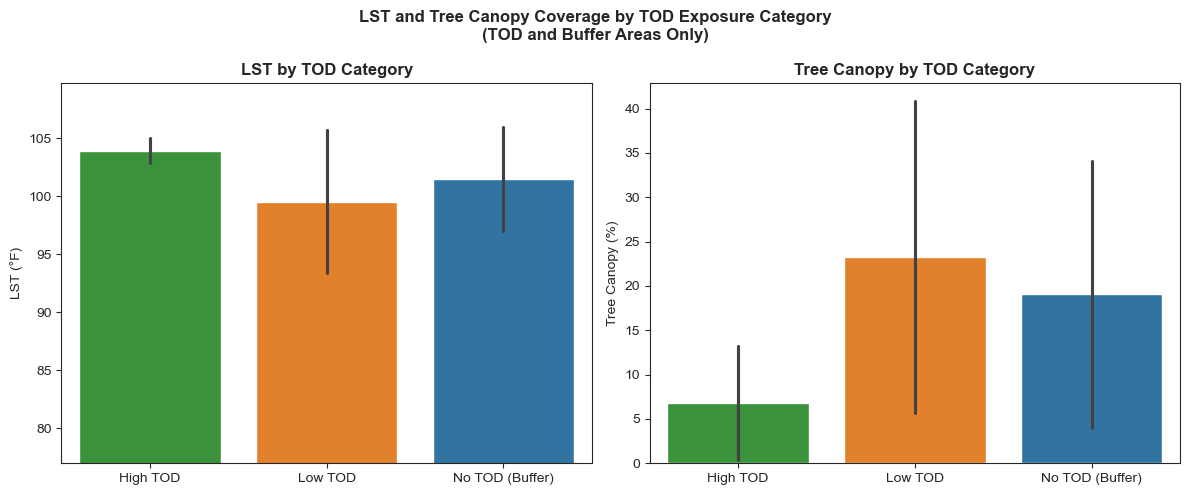

In [98]:
#Create bar charts to showcase how the different TOD exposure types compare against LST values and tree canopy coverage

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Restrict to TOD and buffer tracts for meaningful comparison
plot_data = census_tracts_final[
    census_tracts_final["TOD_category"] != "No TOD (Other)"
].copy()

order = ["High TOD", "Low TOD", "No TOD (Buffer)"]
color_palette = {
    "High TOD" : "#d95F02", 
    "Low TOD" : "#1B9E77", 
    "No TOD (Buffer)" : "#7570B3"
}

#TOD Category vs LST
sns.barplot(
    data=plot_data,
    x="TOD_category", y="LST",
    order=order, hue = "TOD_category",
    ax=axes[0], errorbar="sd"
)
axes[0].set_title("LST by TOD Category", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("LST (°F)")
axes[0].set_ylim(
    plot_data["LST"].min() - 2,
    plot_data["LST"].max() + 2
)

#TOD Category vs Tree Canopy
sns.barplot(
    data=plot_data,
    x="TOD_category", y="canopy",
    order=order, hue = "TOD_category",
    ax=axes[1], errorbar="sd"
)
axes[1].set_title("Tree Canopy by TOD Category", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Tree Canopy (%)")

plt.suptitle(
    "LST and Tree Canopy Coverage by TOD Exposure Category\n"
    "(TOD and Buffer Areas Only)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 5b. Create scatterplots

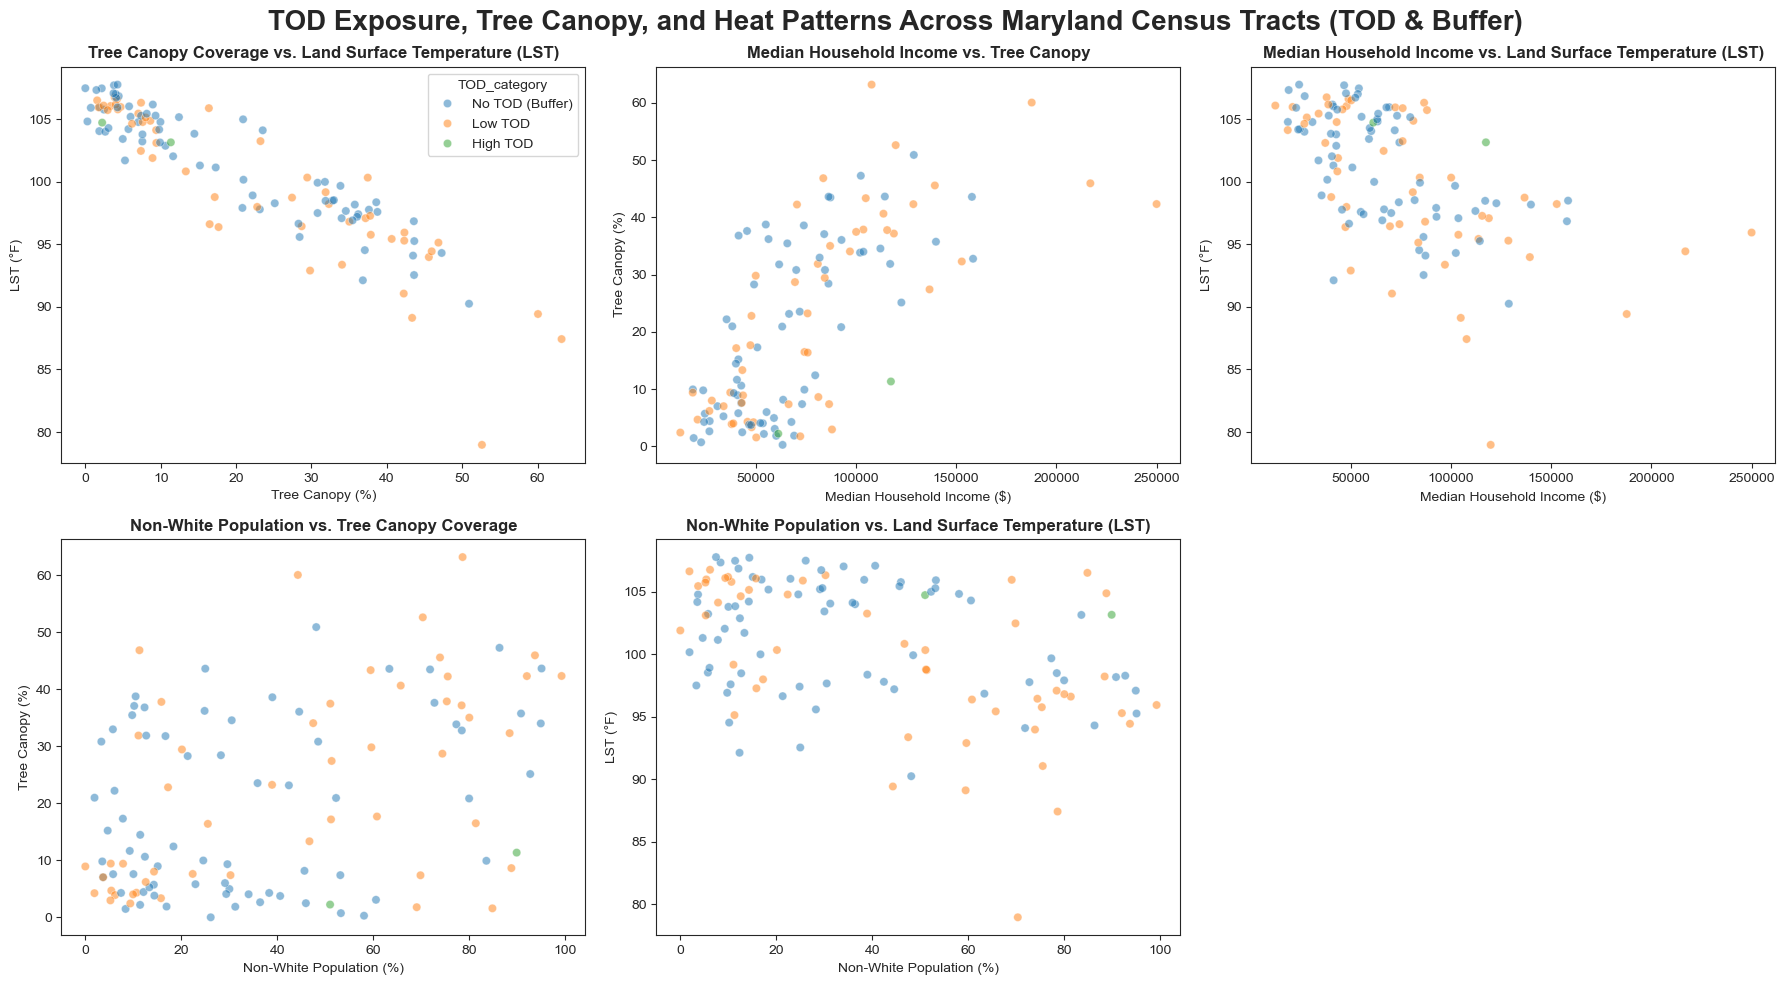

In [99]:
#Create scatterplots to evaluate the relationships between the variables

#Filter to TOD and buffer Census tracts only
plot_data = census_tracts_final[census_tracts_final["TOD_category"] != "No TOD (Other)"].copy()

#Assign the TOD categories different colors so they are easier to identify
color_palette = {
    "High TOD" : "#d95F02", 
    "Low TOD" : "#1B9E77", 
    "No TOD (Buffer)" : "#7570B3"
}

sns.set_style("ticks")

fig, axes = plt.subplots(2, 3, figsize = (18, 10))


#2. Tree Canopy Coverage vs LST
sns.scatterplot(
    data = plot_data, 
    x = "canopy", 
    y = "LST", 
    hue = "TOD_category",
    alpha = 0.5, 
    ax = axes[0, 0],
    legend = True
)
axes[0,0].set_title("Tree Canopy Coverage vs. Land Surface Temperature (LST)", fontweight = "bold")
axes[0,0].set_xlabel("Tree Canopy (%)")
axes[0,0].set_ylabel("LST (°F)")


#3. Median Household Income vs Tree Canopy 
sns.scatterplot(
    data = plot_data, 
    x = "median_income", 
    y = "canopy", 
    hue = "TOD_category",
    alpha = 0.5, 
    ax = axes[0, 1],
    legend = False 
)
axes[0,1].set_title("Median Household Income vs. Tree Canopy", fontweight = "bold")
axes[0,1].set_xlabel("Median Household Income ($)")
axes[0,1].set_ylabel("Tree Canopy (%)")


#5. Median Household Income vs. LST
sns.scatterplot(
    data = plot_data, 
    x = "median_income", 
    y = "LST", 
    hue = "TOD_category",
    alpha = 0.5, 
    ax = axes[0, 2],
    legend = False
)
axes[0,2].set_title("Median Household Income vs. Land Surface Temperature (LST)", fontweight = "bold")
axes[0,2].set_xlabel("Median Household Income ($)")
axes[0,2].set_ylabel("LST (°F)")

#6. Race vs. Tree Canopy Coverage
sns.scatterplot(
    data = plot_data, 
    x = "percent_nonwhite", 
    y = "canopy", 
    hue = "TOD_category",
    alpha = 0.5, 
    ax = axes[1, 0],
    legend = False
)
axes[1,0].set_title("Non-White Population vs. Tree Canopy Coverage", fontweight = "bold")
axes[1,0].set_xlabel("Non-White Population (%)")
axes[1,0].set_ylabel("Tree Canopy (%)")


#7. Race vs. LST
sns.scatterplot(
    data = plot_data, 
    x = "percent_nonwhite", 
    y = "LST", 
    hue = "TOD_category",
    alpha = 0.5, 
    ax = axes[1, 1],
    legend = False
)
axes[1,1].set_title("Non-White Population vs. Land Surface Temperature (LST)", fontweight = "bold")
axes[1,1].set_xlabel("Non-White Population (%)")
axes[1,1].set_ylabel("LST (°F)")


#Give the scatterplots an appropriate title
plt.suptitle(
    "TOD Exposure, Tree Canopy, and Heat Patterns Across Maryland Census Tracts (TOD & Buffer)", 
    fontsize = 20, 
    fontweight = "bold"
)

axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


### 5c. Run an Ordinary Least Squares (OLD) regression to isolate the variable for LST

In [100]:
#All tracts will be used for the regression mode, so those with missing values in the regression variables will need to be dropped

regression_variables = ["LST", "percent_TOD", "canopy", "median_income", "percent_nonwhite", "population_density"]
regression_data = census_tracts_final.dropna(subset = regression_variables).copy()

#Display the results
print("Tracts in the full dataset:", len(census_tracts_final))
print("Tracts used in the regression:", len(regression_data))
print("Tracts dropped (missing data):", len(census_tracts_final) - len(regression_data))

#Check which variables have missing values
print("Missing values per variable:")
print(census_tracts_final[regression_variables].isna().sum())

Tracts in the full dataset: 1391
Tracts used in the regression: 1370
Tracts dropped (missing data): 21
Missing values per variable:
LST                    0
percent_TOD            0
canopy                 9
median_income         21
percent_nonwhite      13
population_density    13
dtype: int64


In [101]:
#Run a simple OLS regression model 
X = regression_data[["percent_TOD", "canopy", "population_density", "median_income", "percent_nonwhite"]]

X = sm.add_constant(X)
y = regression_data["LST"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    LST   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     525.5
Date:                Thu, 14 May 2026   Prob (F-statistic):          6.91e-315
Time:                        05:29:16   Log-Likelihood:                -3728.7
No. Observations:                1370   AIC:                             7469.
Df Residuals:                    1364   BIC:                             7501.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                101.3622      0